# Bayesian Optimisation: A Visual Tutorial

This notebook walks through the core ideas behind **Bayesian Optimisation (BO)** step by step, with figures at every stage.

### What problem does BO solve?

We want to find the **minimum (or maximum)** of an expensive black-box function $f(x)$ using as **few evaluations as possible**.

Think: each evaluation is a costly CFD simulation, a physical experiment, or a neural-network training run.

### The two key ingredients

| Component | Role |
|---|---|
| **Surrogate model** (Gaussian Process) | Cheap probabilistic approximation of $f(x)$ |
| **Acquisition function** | Decides *where to sample next* by balancing exploration vs. exploitation |

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern
from scipy.stats import norm
from scipy.optimize import minimize_scalar

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# Reproducibility
rng = np.random.RandomState(42)

---
## 1. The "Expensive" Objective Function

We use a known test function so we can visualise the truth. In practice you would **never** have access to this curve -- only to point evaluations.

$$f(x) = -\sin(3x) - x^2 + 0.7x$$

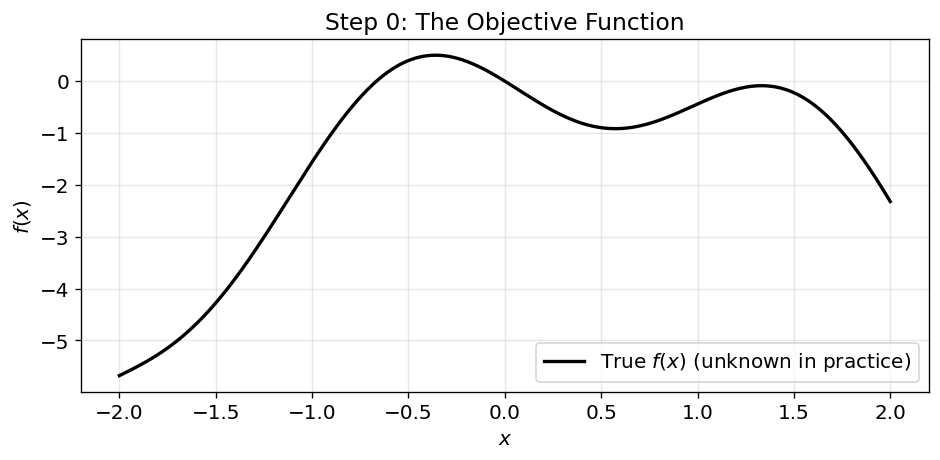

In [2]:
def objective(x):
    """Objective function (expensive to evaluate in real life)."""
    return -np.sin(3 * x) - x**2 + 0.7 * x

X_plot = np.linspace(-2, 2, 400).reshape(-1, 1)
y_plot = objective(X_plot)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(X_plot, y_plot, 'k-', lw=2, label='True $f(x)$ (unknown in practice)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Step 0: The Objective Function')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 2. Initial Samples

BO starts with a **small** set of observations, often chosen at random or with a space-filling design (e.g. Latin Hypercube).

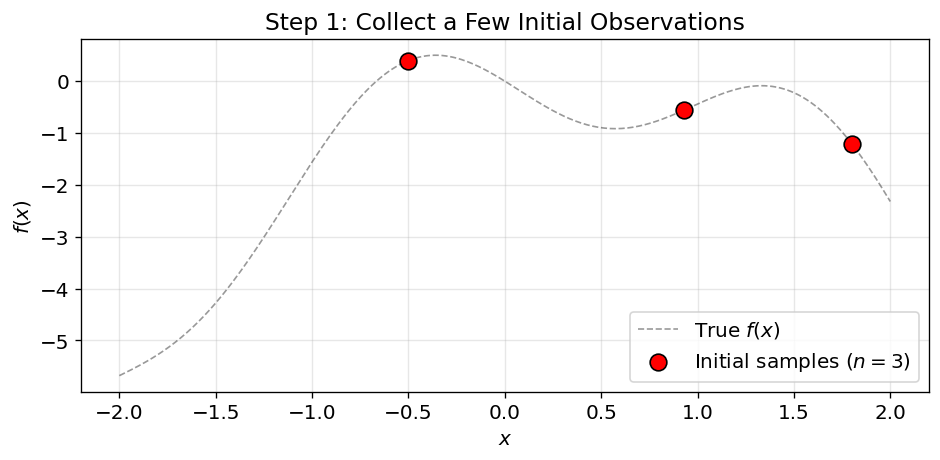

In [3]:
# Draw 3 initial points
X_init = rng.uniform(-2, 2, size=3).reshape(-1, 1)
X_init = np.sort(X_init, axis=0)  # sort for readability
y_init = objective(X_init)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4, label='True $f(x)$')
ax.scatter(X_init, y_init, c='red', s=100, zorder=5, edgecolors='k', label=f'Initial samples ($n={len(X_init)}$)')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Step 1: Collect a Few Initial Observations')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 3. The Surrogate Model: Gaussian Process (GP)

A GP fits a **distribution over functions** that pass through (or near) the observed points.

At every $x$ we get:
- a **mean prediction** $\mu(x)$ -- our best guess
- an **uncertainty band** $\sigma(x)$ -- how confident we are

The uncertainty is **large** where we have no data and **small** near observations.

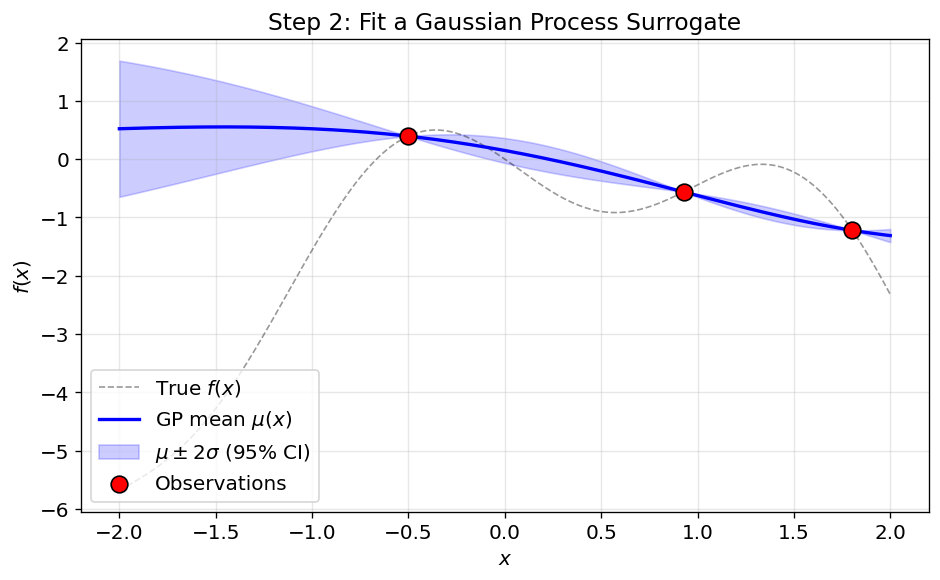

In [4]:
def fit_gp(X_obs, y_obs):
    """Fit a Gaussian Process to the observed data."""
    kernel = Matern(nu=2.5, length_scale=1.0, length_scale_bounds=(0.1, 10))
    gp = GaussianProcessRegressor(
        kernel=kernel, alpha=1e-6, n_restarts_optimizer=5, random_state=42
    )
    gp.fit(X_obs, y_obs)
    return gp

gp = fit_gp(X_init, y_init)
mu, sigma = gp.predict(X_plot, return_std=True)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4, label='True $f(x)$')
ax.plot(X_plot, mu, 'b-', lw=2, label='GP mean $\\mu(x)$')
ax.fill_between(X_plot.ravel(), mu - 2*sigma, mu + 2*sigma,
                alpha=0.2, color='blue', label='$\\mu \\pm 2\\sigma$ (95% CI)')
ax.scatter(X_init, y_init, c='red', s=100, zorder=5, edgecolors='k', label='Observations')
ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title('Step 2: Fit a Gaussian Process Surrogate')
ax.legend(loc='lower left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key observations:**
- Near the red dots the blue band is **narrow** (low uncertainty).
- Far from any observation the band is **wide** (high uncertainty).
- The GP mean may be a poor approximation where data is sparse -- but it *knows* it is uncertain there.

---
## 4. The Acquisition Function

The acquisition function tells us **where to evaluate next**. It balances:

| Strategy | Description |
|---|---|
| **Exploitation** | Sample where $\mu(x)$ is already good |
| **Exploration** | Sample where $\sigma(x)$ is large (high uncertainty) |

### Expected Improvement (EI)

One of the most popular acquisition functions. Given the current best value $f^* = \max y_i$:

$$\text{EI}(x) = (\mu(x) - f^*) \, \Phi(Z) + \sigma(x) \, \phi(Z), \quad Z = \frac{\mu(x) - f^*}{\sigma(x)}$$

where $\Phi$ and $\phi$ are the standard normal CDF and PDF.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14756\2398693944.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


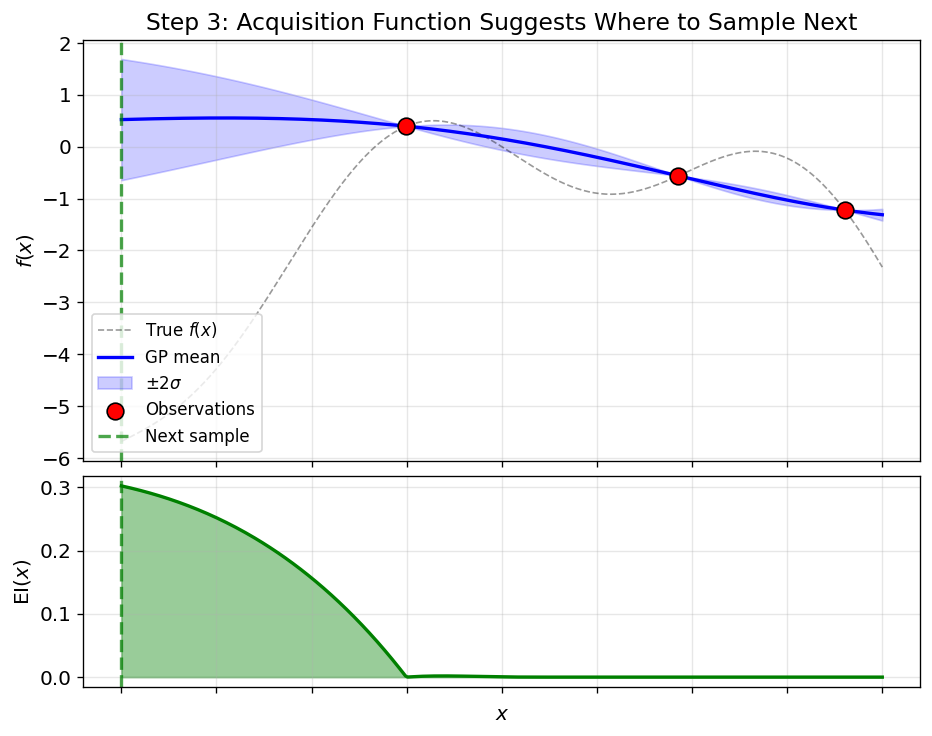

Current best f* = 0.395
Next suggested sample at x = -2.000


In [5]:
def expected_improvement(X, gp, f_best):
    """Compute Expected Improvement at points X."""
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)  # avoid division by zero
    Z = (mu - f_best) / sigma
    ei = (mu - f_best) * norm.cdf(Z) + sigma * norm.pdf(Z)
    return ei

f_best = np.max(y_init)
ei_values = expected_improvement(X_plot, gp, f_best)

# Find the next suggested point
x_next_idx = np.argmax(ei_values)
x_next = X_plot[x_next_idx]

# --- Two-panel figure ---
fig = plt.figure(figsize=(9, 7))
gs = GridSpec(2, 1, height_ratios=[2, 1], hspace=0.05)

# Top: GP surrogate
ax1 = fig.add_subplot(gs[0])
ax1.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4, label='True $f(x)$')
ax1.plot(X_plot, mu, 'b-', lw=2, label='GP mean')
ax1.fill_between(X_plot.ravel(), mu - 2*sigma, mu + 2*sigma,
                 alpha=0.2, color='blue', label='$\\pm 2\\sigma$')
ax1.scatter(X_init, y_init, c='red', s=100, zorder=5, edgecolors='k', label='Observations')
ax1.axvline(x_next, color='green', ls='--', lw=2, alpha=0.7, label='Next sample')
ax1.set_ylabel('$f(x)$')
ax1.set_title('Step 3: Acquisition Function Suggests Where to Sample Next')
ax1.legend(loc='lower left', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xticklabels([])

# Bottom: Acquisition function
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.fill_between(X_plot.ravel(), 0, ei_values, alpha=0.4, color='green')
ax2.plot(X_plot, ei_values, 'g-', lw=2)
ax2.axvline(x_next, color='green', ls='--', lw=2, alpha=0.7)
ax2.set_xlabel('$x$')
ax2.set_ylabel('EI$(x)$')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Current best f* = {f_best:.3f}')
print(f'Next suggested sample at x = {x_next[0]:.3f}')

**Reading the figure:**
- The **green shaded area** (bottom panel) is the Expected Improvement.
- Its peak (green dashed line) is where the algorithm will sample next.
- Notice how EI is high where the GP is **uncertain** *and* the mean looks **promising**.

---
## 5. The BO Loop: Iterate!

The full algorithm repeats:

1. **Fit GP** to all observations so far
2. **Maximise the acquisition function** to pick the next $x$
3. **Evaluate** $f(x_{\text{new}})$ (the expensive step)
4. **Add** the new observation and go to 1

Below we run **7 iterations** and show how the surrogate improves.

In [6]:
def bo_step(X_obs, y_obs):
    """One iteration of Bayesian Optimisation. Returns x_next."""
    gp = fit_gp(X_obs, y_obs)
    f_best = np.max(y_obs)
    ei = expected_improvement(X_plot, gp, f_best)
    x_next = X_plot[np.argmax(ei)].reshape(1, 1)
    return x_next, gp, ei

# Run the loop and store history for plotting
X_obs = X_init.copy()
y_obs = y_init.copy()
n_iterations = 7
history = []  # store snapshots for the iteration figure

for i in range(n_iterations):
    x_new, gp, ei = bo_step(X_obs, y_obs)
    y_new = objective(x_new)
    
    history.append({
        'iter': i + 1,
        'X_obs': X_obs.copy(),
        'y_obs': y_obs.copy(),
        'x_new': x_new.copy(),
        'y_new': y_new.copy(),
        'gp': gp,
        'ei': ei.copy(),
    })
    
    X_obs = np.vstack([X_obs, x_new])
    y_obs = np.vstack([y_obs, y_new])

print(f'After {n_iterations} iterations: best f(x) = {np.max(y_obs):.4f}')
print(f'True optimum: f(x*) = {np.max(y_plot):.4f}')

After 7 iterations: best f(x) = 0.5003
True optimum: f(x*) = 0.5003


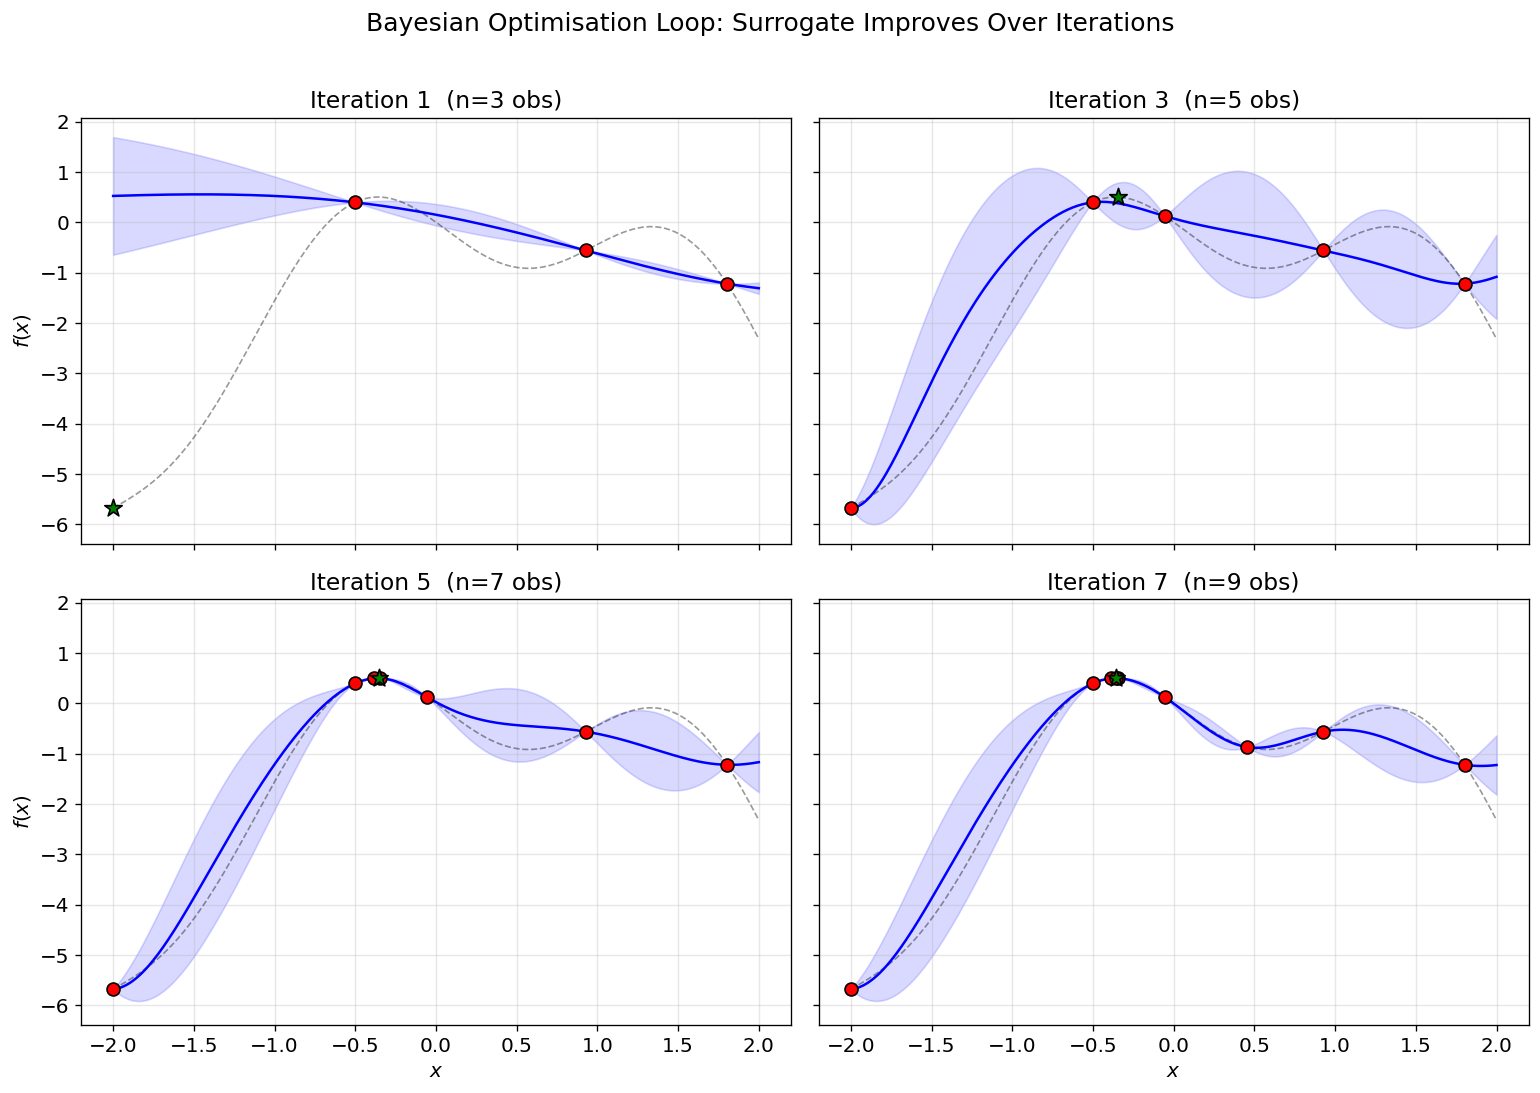

In [7]:
# Show iterations 1, 3, 5, 7 in a 2x2 grid
show_iters = [0, 2, 4, 6]  # indices into history

fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)

for ax, idx in zip(axes.ravel(), show_iters):
    h = history[idx]
    mu, sigma = h['gp'].predict(X_plot, return_std=True)
    
    ax.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4)
    ax.plot(X_plot, mu, 'b-', lw=1.5)
    ax.fill_between(X_plot.ravel(), mu - 2*sigma, mu + 2*sigma, alpha=0.15, color='blue')
    ax.scatter(h['X_obs'], h['y_obs'], c='red', s=60, zorder=5, edgecolors='k')
    ax.scatter(h['x_new'], h['y_new'], c='green', s=120, zorder=6,
              edgecolors='k', marker='*', label='New sample')
    ax.set_title(f"Iteration {h['iter']}  (n={len(h['X_obs'])} obs)")
    ax.grid(True, alpha=0.3)

axes[1, 0].set_xlabel('$x$')
axes[1, 1].set_xlabel('$x$')
axes[0, 0].set_ylabel('$f(x)$')
axes[1, 0].set_ylabel('$f(x)$')

fig.suptitle('Bayesian Optimisation Loop: Surrogate Improves Over Iterations',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

**What to notice in the 2x2 grid:**
- The uncertainty band **shrinks** as more points are added.
- The GP mean **converges** toward the true function.
- The green star (new sample) moves toward the true optimum over time.

---
## 6. Convergence: How Quickly Does BO Find the Optimum?

We plot the **best value found so far** versus the number of function evaluations.

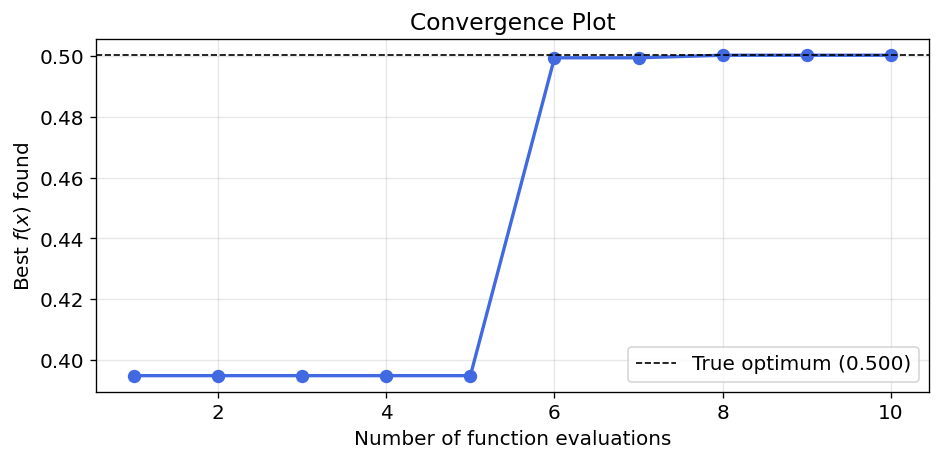

In [8]:
# Build convergence curve
all_y = np.vstack([y_init] + [h['y_new'] for h in history])
best_so_far = np.maximum.accumulate(all_y)

true_opt = np.max(y_plot)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(best_so_far)+1), best_so_far, 'o-', color='royalblue', lw=2, ms=7)
ax.axhline(true_opt, color='k', ls='--', lw=1, label=f'True optimum ({true_opt:.3f})')
ax.set_xlabel('Number of function evaluations')
ax.set_ylabel('Best $f(x)$ found')
ax.set_title('Convergence Plot')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 7. Exploration vs. Exploitation Visualised

To build intuition, let's decompose what the acquisition function is doing.

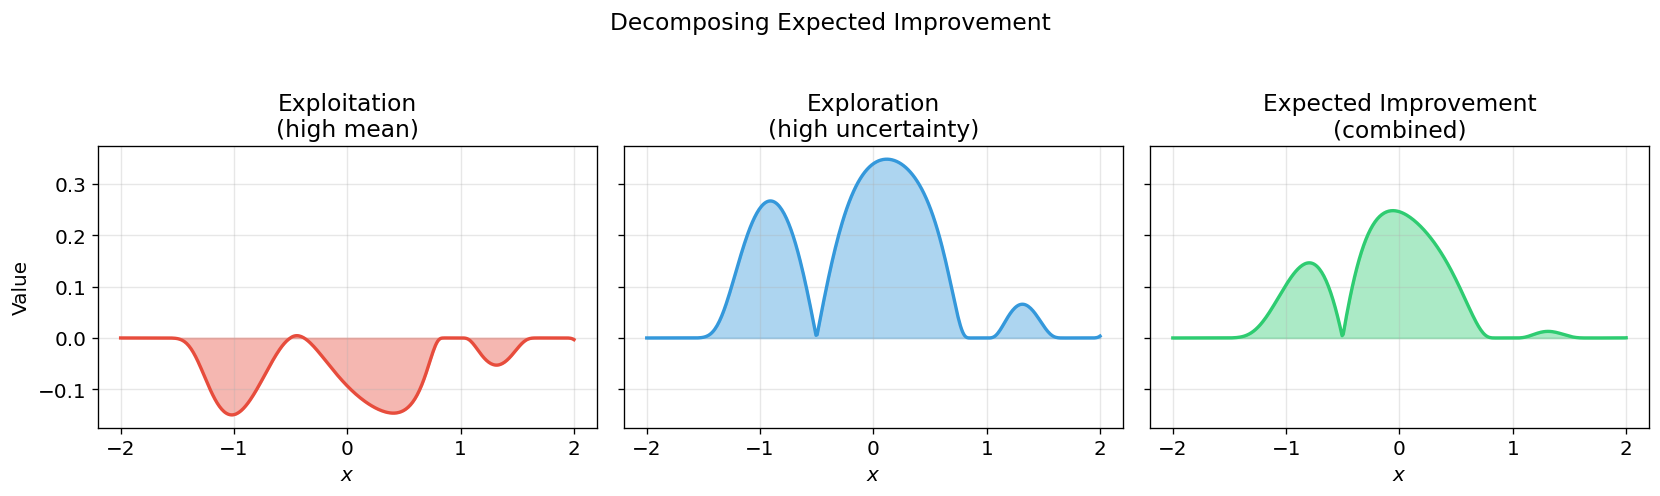

In [9]:
# Use the GP after 2 iterations (still uncertain) for a clear illustration
h = history[1]
gp_demo = h['gp']
mu_demo, sigma_demo = gp_demo.predict(X_plot, return_std=True)
f_best_demo = np.max(h['y_obs'])

# Decompose EI into exploitation and exploration terms
Z = (mu_demo - f_best_demo) / np.maximum(sigma_demo, 1e-9)
exploitation = (mu_demo - f_best_demo) * norm.cdf(Z)
exploration = sigma_demo * norm.pdf(Z)
ei_total = exploitation + exploration

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, vals, title, color in zip(
    axes,
    [exploitation, exploration, ei_total],
    ['Exploitation\n(high mean)', 'Exploration\n(high uncertainty)', 'Expected Improvement\n(combined)'],
    ['#e74c3c', '#3498db', '#2ecc71']
):
    ax.fill_between(X_plot.ravel(), 0, vals, alpha=0.4, color=color)
    ax.plot(X_plot, vals, color=color, lw=2)
    ax.set_title(title)
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('Value')
fig.suptitle('Decomposing Expected Improvement', fontsize=14, y=1.03)
plt.tight_layout()
plt.show()

**Reading the decomposition:**
- **Left (Exploitation):** high where the GP mean is above $f^*$ -- regions we *already think* are good.
- **Middle (Exploration):** high where $\sigma$ is large -- regions we *haven't explored yet*.
- **Right (EI = sum):** the balanced trade-off that BO actually uses.

---
## 8. Comparison: BO vs. Random Search

To see why BO is valuable, let's compare it with naive random sampling using the same evaluation budget.

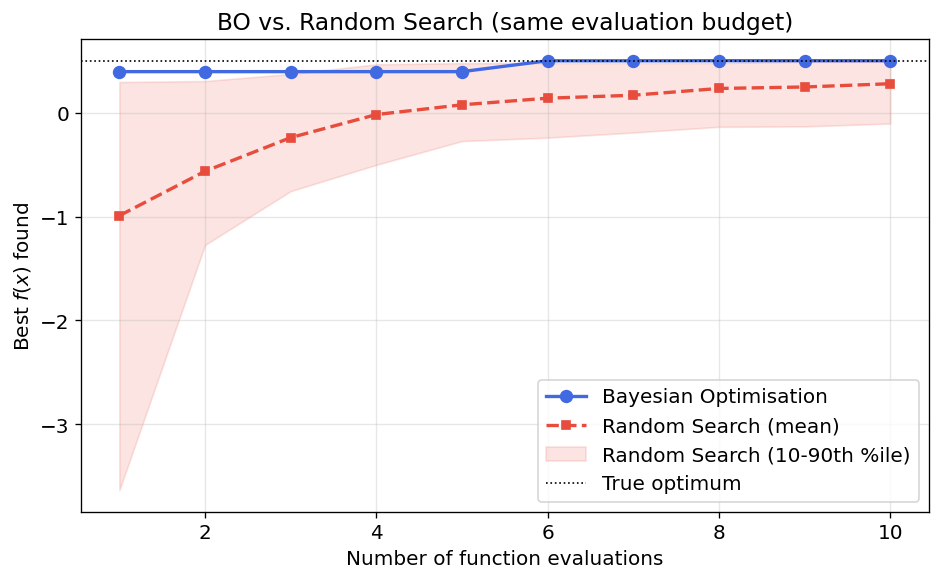

In [10]:
n_total = len(X_init) + n_iterations  # same budget
n_random_trials = 50  # repeat random search many times

random_best_curves = []
for trial in range(n_random_trials):
    X_rand = rng.uniform(-2, 2, size=n_total).reshape(-1, 1)
    y_rand = objective(X_rand)
    random_best_curves.append(np.maximum.accumulate(y_rand).ravel())

random_best_curves = np.array(random_best_curves)
rand_mean = random_best_curves.mean(axis=0)
rand_q10 = np.percentile(random_best_curves, 10, axis=0)
rand_q90 = np.percentile(random_best_curves, 90, axis=0)

evals = np.arange(1, n_total + 1)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(evals, best_so_far.ravel(), 'o-', color='royalblue', lw=2, ms=7, label='Bayesian Optimisation')
ax.plot(evals, rand_mean, 's--', color='#e74c3c', lw=2, ms=5, label='Random Search (mean)')
ax.fill_between(evals, rand_q10, rand_q90, alpha=0.15, color='#e74c3c', label='Random Search (10-90th %ile)')
ax.axhline(true_opt, color='k', ls=':', lw=1, label=f'True optimum')
ax.set_xlabel('Number of function evaluations')
ax.set_ylabel('Best $f(x)$ found')
ax.set_title('BO vs. Random Search (same evaluation budget)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 9. Comparing Acquisition Functions: EI vs. PI vs. UCB

The choice of acquisition function changes **how aggressively** the algorithm explores vs. exploits. Let's define all three and run them side by side from the **same initial samples**.

| Acquisition Function | Formula (maximisation) | Behaviour |
|---|---|---|
| **Expected Improvement (EI)** | $(\mu - f^*)\Phi(Z) + \sigma\phi(Z)$ | Balanced explore/exploit |
| **Probability of Improvement (PI)** | $\Phi(Z)$ | Greedy -- exploits heavily |
| **Upper Confidence Bound (UCB)** | $\mu + \kappa\sigma$ | Tuneable via $\kappa$ (we use $\kappa=2$) |

where $Z = \dfrac{\mu(x) - f^*}{\sigma(x)}$

In [11]:
def probability_of_improvement(X, gp, f_best, xi=0.01):
    """Probability of Improvement: P(f(x) > f_best + xi)."""
    mu, sigma = gp.predict(X, return_std=True)
    sigma = np.maximum(sigma, 1e-9)
    Z = (mu - f_best - xi) / sigma
    return norm.cdf(Z)

def upper_confidence_bound(X, gp, kappa=2.0):
    """Upper Confidence Bound: mu + kappa * sigma."""
    mu, sigma = gp.predict(X, return_std=True)
    return mu + kappa * sigma

### 9.1 What each acquisition function looks like on the same GP

Before running the full loop, let's visualise all three acquisition functions on the **same surrogate** (fitted to the initial 3 points) so you can see how they differ.

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_14756\2820894877.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


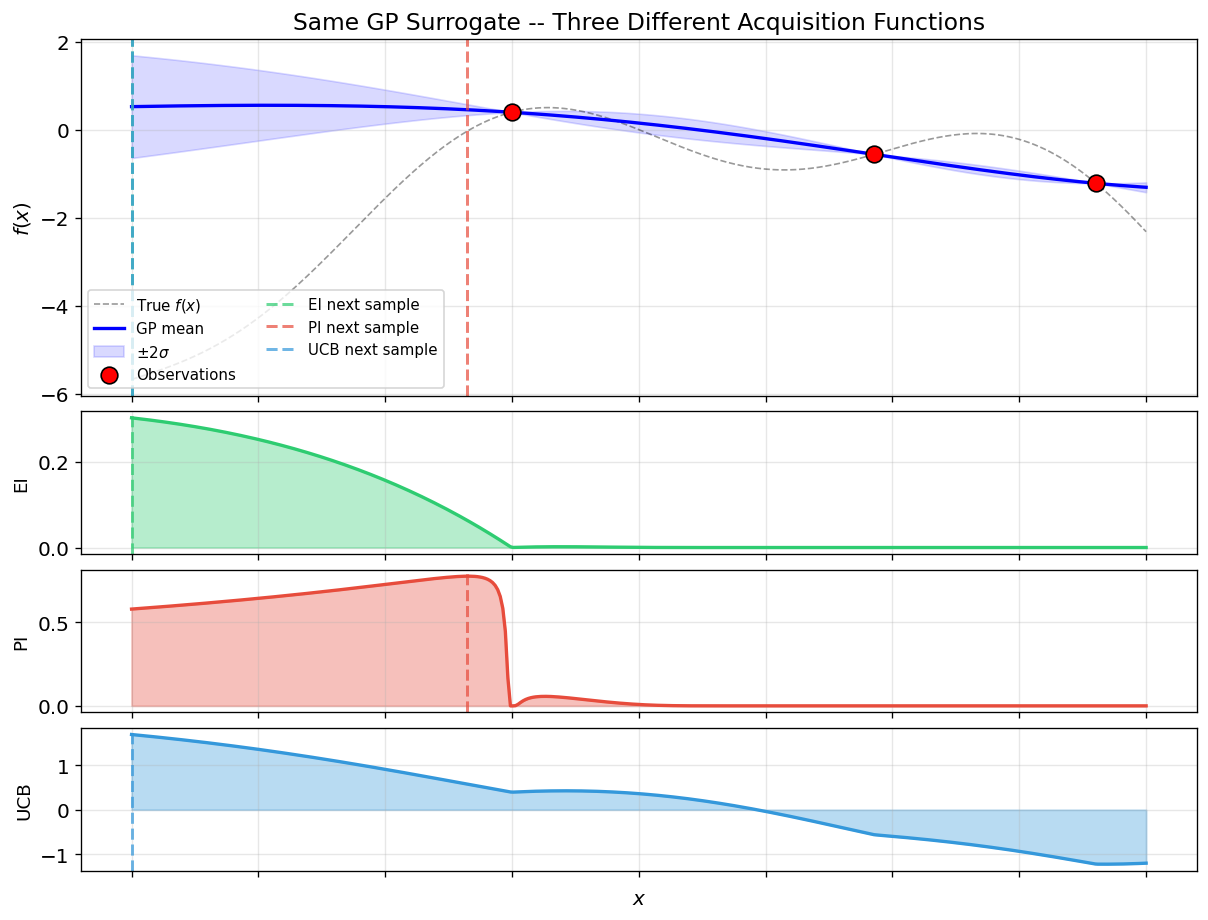

In [12]:
# Fit GP to initial data (same for all three)
gp_compare = fit_gp(X_init, y_init)
mu_c, sigma_c = gp_compare.predict(X_plot, return_std=True)
f_best_c = np.max(y_init)

# Compute all three acquisition functions
ei_vals = expected_improvement(X_plot, gp_compare, f_best_c)
pi_vals = probability_of_improvement(X_plot, gp_compare, f_best_c)
ucb_vals = upper_confidence_bound(X_plot, gp_compare, kappa=2.0)

acq_data = [
    ('Expected Improvement (EI)', ei_vals, '#2ecc71'),
    ('Probability of Improvement (PI)', pi_vals, '#e74c3c'),
    ('Upper Confidence Bound (UCB)', ucb_vals, '#3498db'),
]

fig = plt.figure(figsize=(12, 9))
gs = GridSpec(4, 1, height_ratios=[2.5, 1, 1, 1], hspace=0.08)

# Top panel: GP surrogate
ax0 = fig.add_subplot(gs[0])
ax0.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4, label='True $f(x)$')
ax0.plot(X_plot, mu_c, 'b-', lw=2, label='GP mean')
ax0.fill_between(X_plot.ravel(), mu_c - 2*sigma_c, mu_c + 2*sigma_c,
                 alpha=0.15, color='blue', label='$\\pm 2\\sigma$')
ax0.scatter(X_init, y_init, c='red', s=100, zorder=5, edgecolors='k', label='Observations')

# Mark next sample for each acquisition function
for name, vals, color in acq_data:
    x_peak = X_plot[np.argmax(vals)]
    short = name.split('(')[1].rstrip(')')
    ax0.axvline(x_peak, color=color, ls='--', lw=1.8, alpha=0.7, label=f'{short} next sample')

ax0.set_ylabel('$f(x)$')
ax0.set_title('Same GP Surrogate -- Three Different Acquisition Functions')
ax0.legend(loc='lower left', fontsize=9, ncol=2)
ax0.grid(True, alpha=0.3)
ax0.set_xticklabels([])

# Bottom panels: one per acquisition function
for i, (name, vals, color) in enumerate(acq_data):
    ax = fig.add_subplot(gs[i + 1], sharex=ax0)
    ax.fill_between(X_plot.ravel(), 0, vals, alpha=0.35, color=color)
    ax.plot(X_plot, vals, color=color, lw=2)
    x_peak = X_plot[np.argmax(vals)]
    ax.axvline(x_peak, color=color, ls='--', lw=1.8, alpha=0.7)
    ax.set_ylabel(name.split('(')[1].rstrip(')'), fontsize=11)
    ax.grid(True, alpha=0.3)
    if i < 2:
        ax.set_xticklabels([])

ax.set_xlabel('$x$')
plt.tight_layout()
plt.show()

**What to notice:**
- **PI** tends to peak near the current best -- it is *greedy* and exploits aggressively.
- **UCB** has a broad peak that extends into uncertain regions -- it *explores* more.
- **EI** sits between the two, balancing both signals.

The dashed vertical lines show where each acquisition function would place the **next sample**.

### 9.2 Full BO loop with each acquisition function

Now let's run the **complete optimisation loop** (7 iterations) using each acquisition function independently, all starting from the same 3 initial points.

In [13]:
def run_bo_loop(X_init, y_init, acq_name, n_iters=7):
    """Run a full BO loop with a given acquisition function."""
    X_obs = X_init.copy()
    y_obs = y_init.copy()
    
    for _ in range(n_iters):
        gp = fit_gp(X_obs, y_obs)
        f_best = np.max(y_obs)
        
        if acq_name == 'EI':
            acq_vals = expected_improvement(X_plot, gp, f_best)
        elif acq_name == 'PI':
            acq_vals = probability_of_improvement(X_plot, gp, f_best)
        elif acq_name == 'UCB':
            acq_vals = upper_confidence_bound(X_plot, gp, kappa=2.0)
        
        x_new = X_plot[np.argmax(acq_vals)].reshape(1, 1)
        y_new = objective(x_new)
        X_obs = np.vstack([X_obs, x_new])
        y_obs = np.vstack([y_obs, y_new])
    
    return X_obs, y_obs

# Run all three from the same starting points
X_ei, y_ei = run_bo_loop(X_init, y_init, 'EI', n_iters=7)
X_pi, y_pi = run_bo_loop(X_init, y_init, 'PI', n_iters=7)
X_ucb, y_ucb = run_bo_loop(X_init, y_init, 'UCB', n_iters=7)

print('Best f(x) found:')
print(f'  EI:  {np.max(y_ei):.4f}')
print(f'  PI:  {np.max(y_pi):.4f}')
print(f'  UCB: {np.max(y_ucb):.4f}')
print(f'  True optimum: {np.max(y_plot):.4f}')

Best f(x) found:
  EI:  0.5003
  PI:  0.4995
  UCB: 0.5003
  True optimum: 0.5003


### 9.3 Where did each method sample?

This figure shows all samples placed by each acquisition function. Notice the different **sampling strategies**.

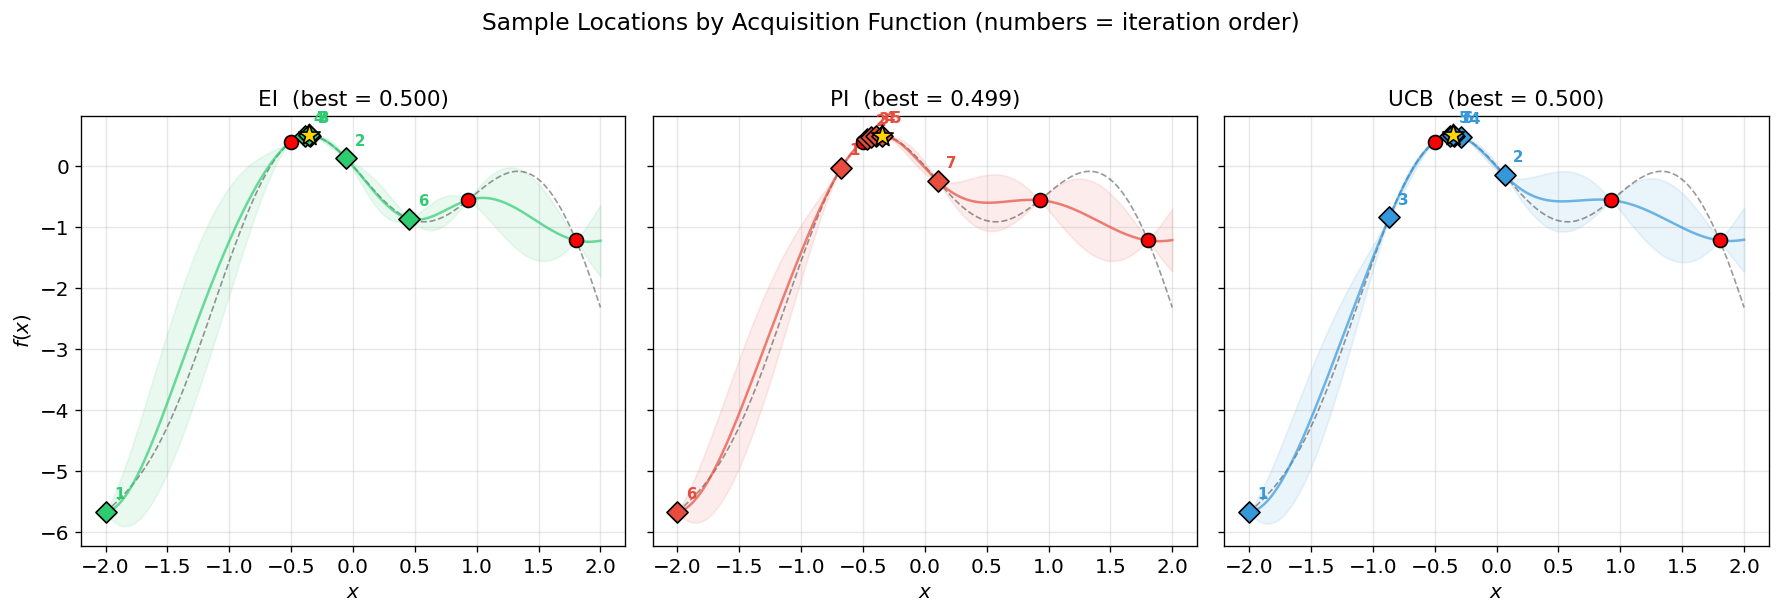

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

n_init = len(X_init)
methods = [
    ('EI', X_ei, y_ei, '#2ecc71'),
    ('PI', X_pi, y_pi, '#e74c3c'),
    ('UCB', X_ucb, y_ucb, '#3498db'),
]

for ax, (name, X_m, y_m, color) in zip(axes, methods):
    ax.plot(X_plot, y_plot, 'k--', lw=1, alpha=0.4, label='True $f(x)$')
    
    # Fit final GP for this method
    gp_m = fit_gp(X_m, y_m)
    mu_m, sigma_m = gp_m.predict(X_plot, return_std=True)
    ax.plot(X_plot, mu_m, color=color, lw=1.5, alpha=0.7)
    ax.fill_between(X_plot.ravel(), mu_m - 2*sigma_m, mu_m + 2*sigma_m,
                    alpha=0.1, color=color)
    
    # Initial samples
    ax.scatter(X_m[:n_init], y_m[:n_init], c='red', s=70, zorder=5,
              edgecolors='k', label='Initial')
    # BO-selected samples (numbered)
    for j in range(n_init, len(X_m)):
        ax.scatter(X_m[j], y_m[j], c=color, s=80, zorder=5,
                  edgecolors='k', marker='D')
        ax.annotate(str(j - n_init + 1), (X_m[j, 0], y_m[j, 0]),
                   textcoords='offset points', xytext=(5, 8),
                   fontsize=9, fontweight='bold', color=color)
    
    # Best found
    best_idx = np.argmax(y_m)
    ax.scatter(X_m[best_idx], y_m[best_idx], c='gold', s=180, zorder=6,
              edgecolors='k', marker='*')
    
    ax.set_title(f'{name}  (best = {np.max(y_m):.3f})', fontsize=13)
    ax.set_xlabel('$x$')
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel('$f(x)$')
fig.suptitle('Sample Locations by Acquisition Function (numbers = iteration order)',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Observations:**
- **PI** clusters its samples tightly around the region it first found promising -- pure exploitation.
- **UCB** spreads samples more broadly, exploring uncertain regions even if the mean is not high.
- **EI** strikes a middle ground, exploring somewhat but converging toward the optimum.

### 9.4 Convergence comparison

Which acquisition function reaches the optimum fastest?

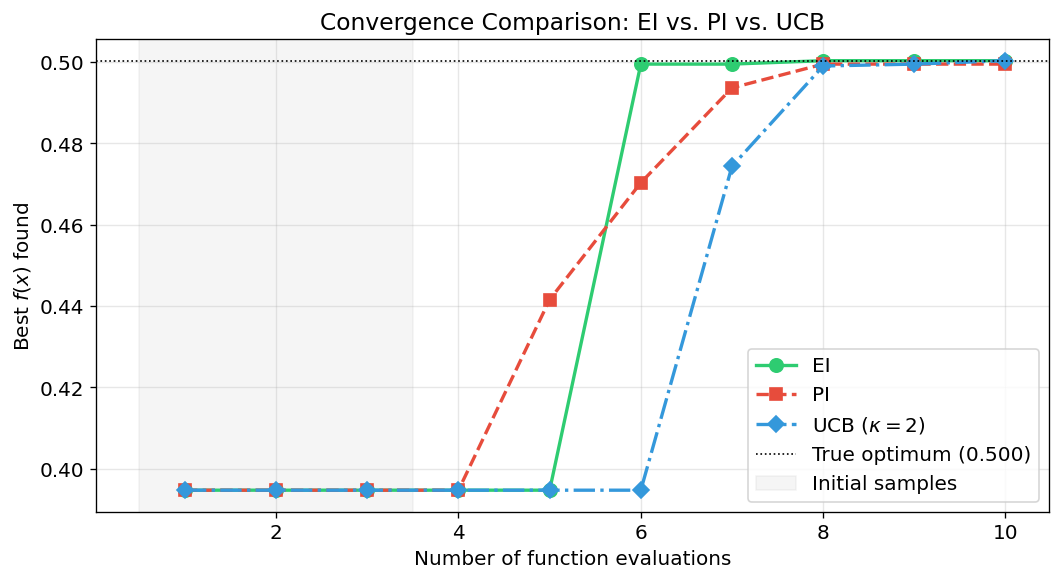

In [15]:
def convergence_curve(y_all):
    return np.maximum.accumulate(y_all).ravel()

conv_ei = convergence_curve(y_ei)
conv_pi = convergence_curve(y_pi)
conv_ucb = convergence_curve(y_ucb)
evals_all = np.arange(1, len(conv_ei) + 1)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(evals_all, conv_ei, 'o-', color='#2ecc71', lw=2, ms=8, label='EI')
ax.plot(evals_all, conv_pi, 's--', color='#e74c3c', lw=2, ms=7, label='PI')
ax.plot(evals_all, conv_ucb, 'D-.', color='#3498db', lw=2, ms=7, label='UCB ($\\kappa=2$)')
ax.axhline(true_opt, color='k', ls=':', lw=1, label=f'True optimum ({true_opt:.3f})')

ax.axvspan(0.5, n_init + 0.5, alpha=0.08, color='grey', label='Initial samples')

ax.set_xlabel('Number of function evaluations')
ax.set_ylabel('Best $f(x)$ found')
ax.set_title('Convergence Comparison: EI vs. PI vs. UCB')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Key takeaway:** No single acquisition function is universally best. The right choice depends on your problem:

| If you want... | Use |
|---|---|
| A safe, general-purpose default | **EI** |
| Quick convergence when the landscape is simple | **PI** (but risk getting stuck) |
| More exploration / robustness to local optima | **UCB** with $\kappa \geq 2$ |

---
## 10. Final Result

Let's show the final GP after all iterations (using EI), overlaid with every sample taken.

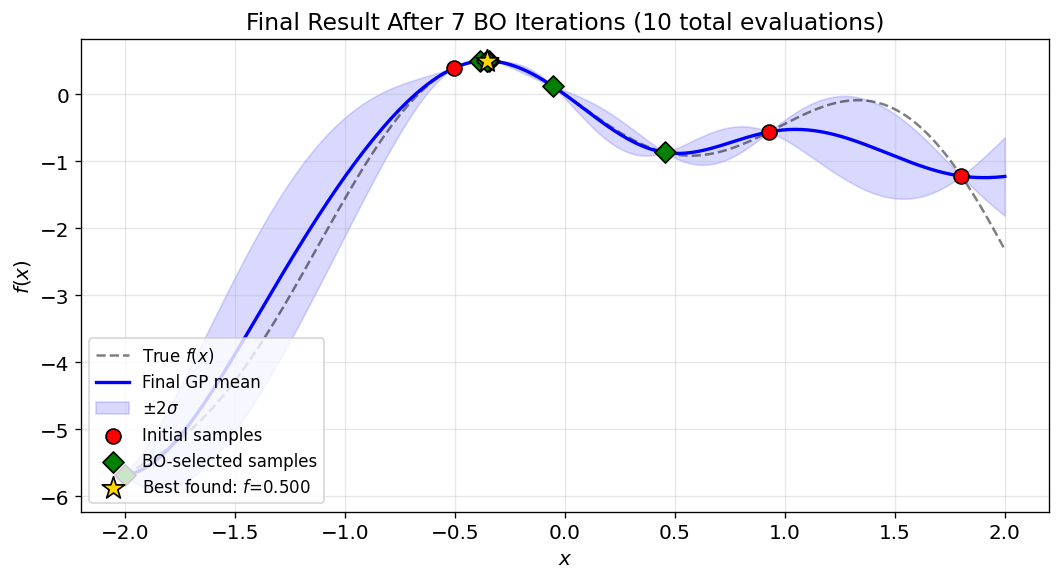

In [16]:
gp_final = fit_gp(X_obs, y_obs)
mu_final, sigma_final = gp_final.predict(X_plot, return_std=True)

best_idx = np.argmax(y_obs)
x_best = X_obs[best_idx]
y_best = y_obs[best_idx]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(X_plot, y_plot, 'k--', lw=1.5, alpha=0.5, label='True $f(x)$')
ax.plot(X_plot, mu_final, 'b-', lw=2, label='Final GP mean')
ax.fill_between(X_plot.ravel(), mu_final - 2*sigma_final, mu_final + 2*sigma_final,
                alpha=0.15, color='blue', label='$\\pm 2\\sigma$')

# Initial samples
ax.scatter(X_init, y_init, c='red', s=80, zorder=5, edgecolors='k', label='Initial samples')
# BO-selected samples
ax.scatter(X_obs[len(X_init):], y_obs[len(X_init):], c='green', s=80, zorder=5,
          edgecolors='k', marker='D', label='BO-selected samples')
# Best found
ax.scatter(x_best, y_best, c='gold', s=200, zorder=6, edgecolors='k',
          marker='*', label=f'Best found: $f$={y_best[0]:.3f}')

ax.set_xlabel('$x$')
ax.set_ylabel('$f(x)$')
ax.set_title(f'Final Result After {n_iterations} BO Iterations ({len(X_obs)} total evaluations)')
ax.legend(loc='lower left', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 11. Summary: The Bayesian Optimisation Algorithm

```
1. Choose initial design points and evaluate f(x)
2. REPEAT until budget exhausted:
   a. Fit a Gaussian Process to all observations
   b. Compute the acquisition function (e.g. Expected Improvement)
   c. Find x_next = argmax acquisition(x)
   d. Evaluate y_next = f(x_next)        <-- the expensive step
   e. Add (x_next, y_next) to the dataset
3. Return the best observed point
```

### When to use Bayesian Optimisation

| Good fit | Poor fit |
|---|---|
| Expensive evaluations (simulations, experiments) | Cheap evaluations (can afford thousands of calls) |
| Low-dimensional input space (typically < 20 parameters) | Very high-dimensional spaces |
| Smooth, continuous objective | Highly discrete or combinatorial problems |
| Black-box function (no gradients available) | Gradient information is available (use gradient descent) |

### Common acquisition functions

| Name | Key idea | Character |
|---|---|---|
| **Expected Improvement (EI)** | Expected amount by which we improve over $f^*$ | Balanced (default choice) |
| **Probability of Improvement (PI)** | Probability of beating $f^*$ | Exploitative / greedy |
| **Upper Confidence Bound (UCB)** | $\mu(x) + \kappa \sigma(x)$; tuneable $\kappa$ | Explorative (high $\kappa$) |
| **Knowledge Gradient** | One-step look-ahead value of information | Theoretically optimal but expensive |

---

### References & Further Reading

- Brochu, Cora & de Freitas (2010). *A Tutorial on Bayesian Optimization*.
- Shahriari et al. (2016). *Taking the Human Out of the Loop: A Review of Bayesian Optimization*. Proceedings of the IEEE.
- Frazier (2018). *A Tutorial on Bayesian Optimization*. arXiv:1807.02811.